In [2]:
%pip install yfinance

  Using cached yfinance-0.2.65-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached peewee-3.18.2.tar.gz (949 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached beautifulsoup4-4.13.4-py3-none-any.whl.metadata (3.8 kB)
  Using cached soupsieve-2.7-py3-none-any.whl.metadata (4.6 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached yfinance-0.2.65-py2.py3-none-any.whl (119 kB)
Using cached beautifulsoup4-4.13.4-py3-none-any.whl (187 kB)
   -----------

In [3]:
import yfinance as yf
import numpy as np

In [4]:
T = 200
N = 5
use_yfinance = True

In [5]:
default_prices = np.cumsum(np.random.randn(T, N) * 2 + 100, axis=0)
print(default_prices)

[[   99.34563381    96.44331374    98.19510934   100.2552696
    103.37419747]
 [  201.43809944   194.31277756   199.27942913   199.2922519
    201.39447103]
 [  300.59699859   295.6168453    298.97086555   298.34126131
    301.17158581]
 [  398.28064388   391.5949793    397.42523708   396.27270945
    400.59957404]
 [  499.31390178   493.84129646   496.05577213   496.37487719
    503.99790903]
 [  602.78495095   596.41721109   596.4325715    595.75644389
    607.38060953]
 [  703.75654837   696.22360856   693.86745621   697.81842654
    707.90012003]
 [  800.46287009   794.34769766   799.87785733   796.88261283
    807.2453049 ]
 [  901.24639854   892.49265582   902.54923865   897.79865355
    908.39140498]
 [ 1000.80375506   990.96190384   999.51378642   997.8864341
   1006.43563925]
 [ 1100.29923917  1088.56321737  1097.44522438  1097.64484215
   1110.06178433]
 [ 1200.09226952  1187.60524114  1197.19353585  1200.24926659
   1211.98382215]
 [ 1301.69773795  1286.15426632  1298.31706

In [17]:
tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA']
df = yf.download(tickers, threads=False)

C:\Users\inula\AppData\Local\Temp\ipykernel_38196\3574174439.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, threads=False)
[*********************100%***********************]  5 of 5 completed


In [20]:
df['Close']

Ticker,AAPL,AMZN,GOOG,MSFT,TSLA
Date,,,,,
2025-06-24,200.300003,212.770004,167.740005,490.109985,340.470001
2025-06-25,201.559998,211.990005,171.490005,492.269989,327.549988
2025-06-26,201.000000,217.119995,174.429993,497.450012,325.779999
2025-06-27,201.080002,223.300003,178.270004,495.940002,323.630005
2025-06-30,205.169998,219.389999,177.389999,497.410004,317.660004
2025-07-01,207.820007,220.460007,176.910004,492.049988,300.709991
2025-07-02,212.440002,219.919998,179.759995,491.089996,315.649994
2025-07-03,213.550003,223.410004,180.550003,498.839996,315.350006
2025-07-07,209.949997,223.470001,177.559998,497.720001,293.940002


In [7]:
tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA']
data = {}

for t in tickers:
    stock = yf.Ticker(t)
    hist = stock.history(period="1mo")  # or start/end dates
    data[t] = hist

# Example: print AAPL data
print(data['AAPL'].head())

                                 Open        High         Low       Close  \
Date                                                                        
2025-06-24 00:00:00-04:00  202.589996  203.440002  200.199997  200.300003   
2025-06-25 00:00:00-04:00  201.449997  203.669998  200.619995  201.559998   
2025-06-26 00:00:00-04:00  201.429993  202.639999  199.460007  201.000000   
2025-06-27 00:00:00-04:00  201.889999  203.220001  200.000000  201.080002   
2025-06-30 00:00:00-04:00  202.009995  207.389999  199.259995  205.169998   

                             Volume  Dividends  Stock Splits  
Date                                                          
2025-06-24 00:00:00-04:00  54064000        0.0           0.0  
2025-06-25 00:00:00-04:00  39525700        0.0           0.0  
2025-06-26 00:00:00-04:00  50799100        0.0           0.0  
2025-06-27 00:00:00-04:00  73188600        0.0           0.0  
2025-06-30 00:00:00-04:00  91912800        0.0           0.0  


In [8]:
prices = df.values
if prices.shape[0] > T:
    prices = prices[-T:]
# If less than N tickers returned, pad with last column or truncate
if prices.shape[1] < N:
    last_col = prices[:, -1].reshape(-1,1)
    prices = np.hstack([prices] + [last_col]*(N - prices.shape[1]))
elif prices.shape[1] > N:
    prices = prices[:, :N]

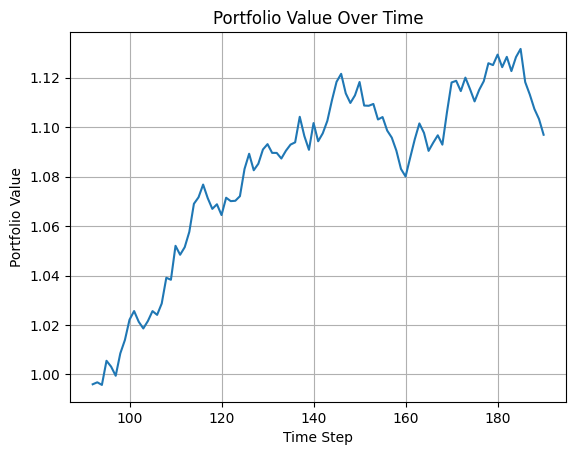

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\inula\OneDrive\ドキュメント\GitHub\GDMOPT\log\data\episode_log_epoch_0.csv")
plt.plot(df["step"], df["portfolio_value"])
plt.title("Portfolio Value Over Time")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Value")
plt.grid()
plt.show()

In [9]:
df

,step,portfolio_value,prev_prices,curr_prices,returns,action,expert_action,sub_expert_action,real_action,reward
0,92,0.996031,"[106.35792898526994, 107.51826146459892, 110.5...","[107.20851816566626, 106.51471947373743, 110.6...","[0.007997421428863373, -0.009333688781713749, ...","[0.1996932476758957, 0.19984841346740723, 0.19...","[0.2, 0.2, 0.2, 0.2, 0.2]","[0.20393971668749422, 0.1846789166956447, 0.19...","[0.1996932476758957, 0.19984841346740723, 0.19...",-0.003977
1,93,0.996828,"[107.20851816566626, 106.51471947373743, 110.6...","[107.06729658304813, 107.65058940784027, 112.4...","[-0.0013172608392917424, 0.010663971512246304,...","[0.1996302455663681, 0.20013882219791412, 0.19...","[0.2, 0.2, 0.2, 0.2, 0.2]","[0.1991300591304799, 0.20943287529033694, 0.20...","[0.1996302455663681, 0.20013882219791412, 0.19...",0.000801
2,94,0.995771,"[107.06729658304813, 107.65058940784027, 112.4...","[106.63749736743151, 106.98983359096806, 111.8...","[-0.00401429035133288, -0.0061379674789229476,...","[0.1999887079000473, 0.1998523771762848, 0.199...","[0.2, 0.2, 0.2, 0.2, 0.2]","[0.21032357432595516, 0.18661444758340096, 0.1...","[0.1999887228012085, 0.19985239207744598, 0.19...",-0.001299
3,95,1.005536,"[106.63749736743151, 106.98983359096806, 111.8...","[108.33064676678659, 105.92351566210603, 115.3...","[0.01587761754686667, -0.009966535072282338, 0...","[0.1993371546268463, 0.1998112052679062, 0.199...","[0.2, 0.2, 0.2, 0.2, 0.2]","[0.20339295302110955, 0.20058115320387765, 0.2...","[0.19933712482452393, 0.1998111754655838, 0.19...",0.009562
4,96,1.003167,"[108.33064676678659, 105.92351566210603, 115.3...","[105.7444549931554, 109.00081143356269, 117.76...","[-0.0238731314805008, 0.02905205470401092, 0.0...","[0.19992733001708984, 0.20028641819953918, 0.1...","[0.2, 0.2, 0.2, 0.2, 0.2]","[0.21607166524491966, 0.19818757913866353, 0.1...","[0.19992733001708984, 0.20028641819953918, 0.1...",-0.002871
...,...,...,...,...,...,...,...,...,...,...
94,186,1.118205,"[110.22279975866644, 126.90618014213278, 131.8...","[109.32888767694239, 126.51395444463348, 128.3...","[-0.008110046956539664, -0.0030906745208153998...","[0.20012718439102173, 0.20006373524665833, 0.1...","[0.2, 0.2, 0.2, 0.2, 0.2]","[0.19482667977743506, 0.21033646323029712, 0.1...","[0.20012718439102173, 0.20006373524665833, 0.1...",-0.012444
95,187,1.113167,"[109.32888767694239, 126.51395444463348, 128.3...","[109.76919660812366, 124.19395540556852, 129.5...","[0.0040273795932357186, -0.018337890466306406,...","[0.1996557116508484, 0.19998973608016968, 0.19...","[0.2, 0.2, 0.2, 0.2, 0.2]","[0.20355278326625503, 0.20183072767056448, 0.1...","[0.199655681848526, 0.1999897062778473, 0.1995...",-0.005049
96,188,1.107334,"[109.76919660812366, 124.19395540556852, 129.5...","[107.02584459200455, 125.9226632861801, 128.18...","[-0.024992002318399875, 0.013919420433678125, ...","[0.2000562846660614, 0.20018313825130463, 0.19...","[0.2, 0.2, 0.2, 0.2, 0.2]","[0.20386417325711997, 0.19872222989031502, 0.1...","[0.2000562846660614, 0.20018313825130463, 0.19...",-0.005787
97,189,1.103267,"[107.02584459200455, 125.9226632861801, 128.18...","[106.56915687666607, 125.39756587563961, 126.8...","[-0.00426707882642201, -0.0041699992426868495,...","[0.1999807059764862, 0.19994506239891052, 0.19...","[0.2, 0.2, 0.2, 0.2, 0.2]","[0.18652172844773435, 0.22325959554105393, 0.1...","[0.1999807357788086, 0.1999450922012329, 0.199...",-0.004215


In [24]:
import os
folder_path = 'log/data'
file_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path)
              if os.path.isfile(os.path.join(folder_path, f))]

In [ ]:
# file_paths = file_paths[1:]

In [25]:
len(file_paths)
paths = file_paths

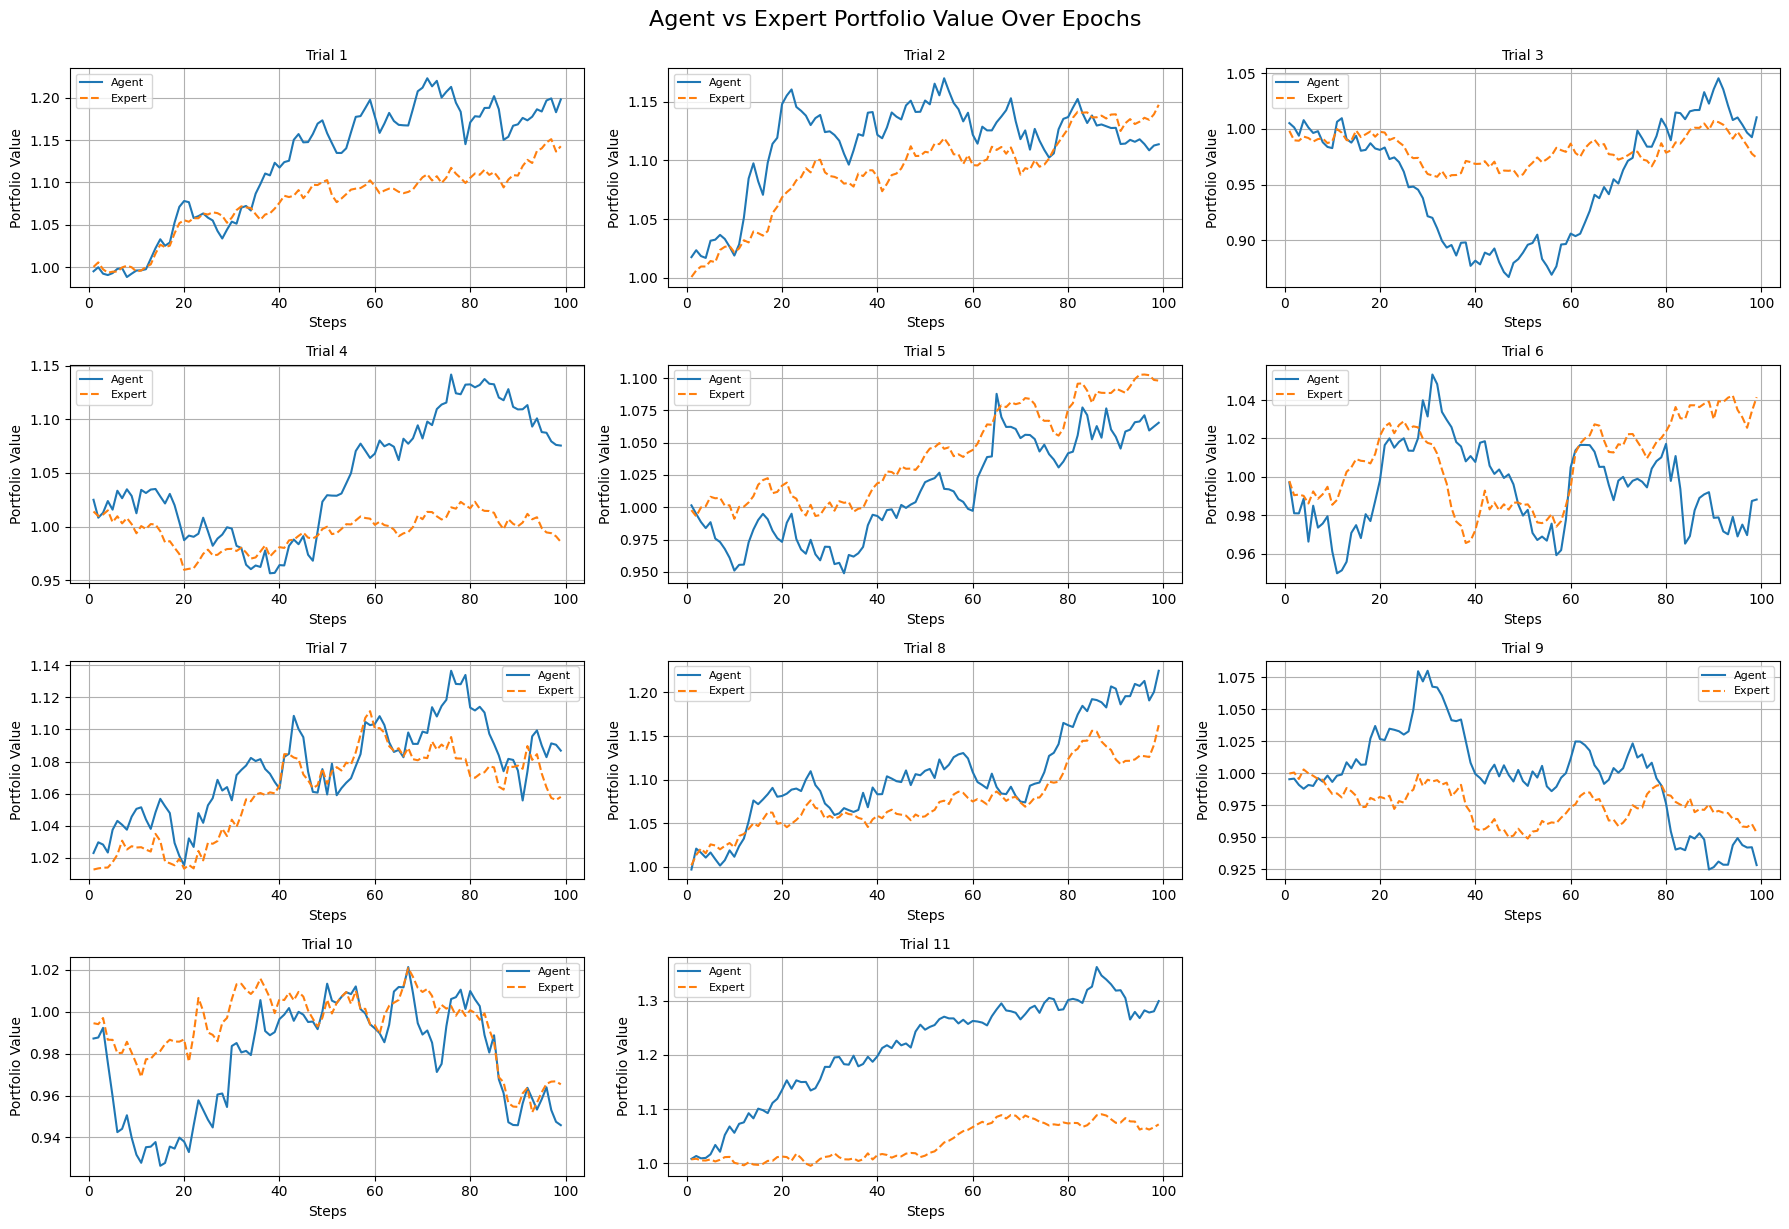

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Define path to the logs
log_dir = r"C:\Users\inula\OneDrive\ドキュメント\GitHub\GDMOPT\log\data"

# Get all CSV file paths
paths = sorted([
    os.path.join(log_dir, f)
    for f in os.listdir(log_dir)
    if f.endswith(".csv")
])

# Setup figure for 3 columns × 4 rows
n = len(paths)
rows, cols = 4, 3
fig, axs = plt.subplots(rows, cols, figsize=(18, 12))
axs = axs.flatten()

for i, path in enumerate(paths):
    df = pd.read_csv(path)
    df["returns"] = df["returns"].apply(eval)
    df["expert_action"] = df["sub_expert_action"].apply(eval)
    df["expert_return"] = df.apply(lambda row: np.dot(row["expert_action"], row["returns"]), axis=1)

    # Compute cumulative expert portfolio values
    expert_portfolio = [1.0]
    for r in df["expert_return"]:
        expert_portfolio.append(expert_portfolio[-1] * (1 + r))
    df["expert_portfolio_value"] = expert_portfolio[1:]

    # Plot in subplot
    ax = axs[i]
    ax.plot(df["step"], df["portfolio_value"], label="Agent", linewidth=1.5)
    ax.plot(df["step"], df["expert_portfolio_value"], label="Expert", linestyle="--", linewidth=1.5)
    ax.set_title(f"Trial {i+1}", fontsize=10)
    ax.set_xlabel("Steps")
    ax.set_ylabel("Portfolio Value")
    ax.grid(True)
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(n, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.suptitle("Agent vs Expert Portfolio Value Over Epochs", fontsize=16, y=1.02)
plt.show()


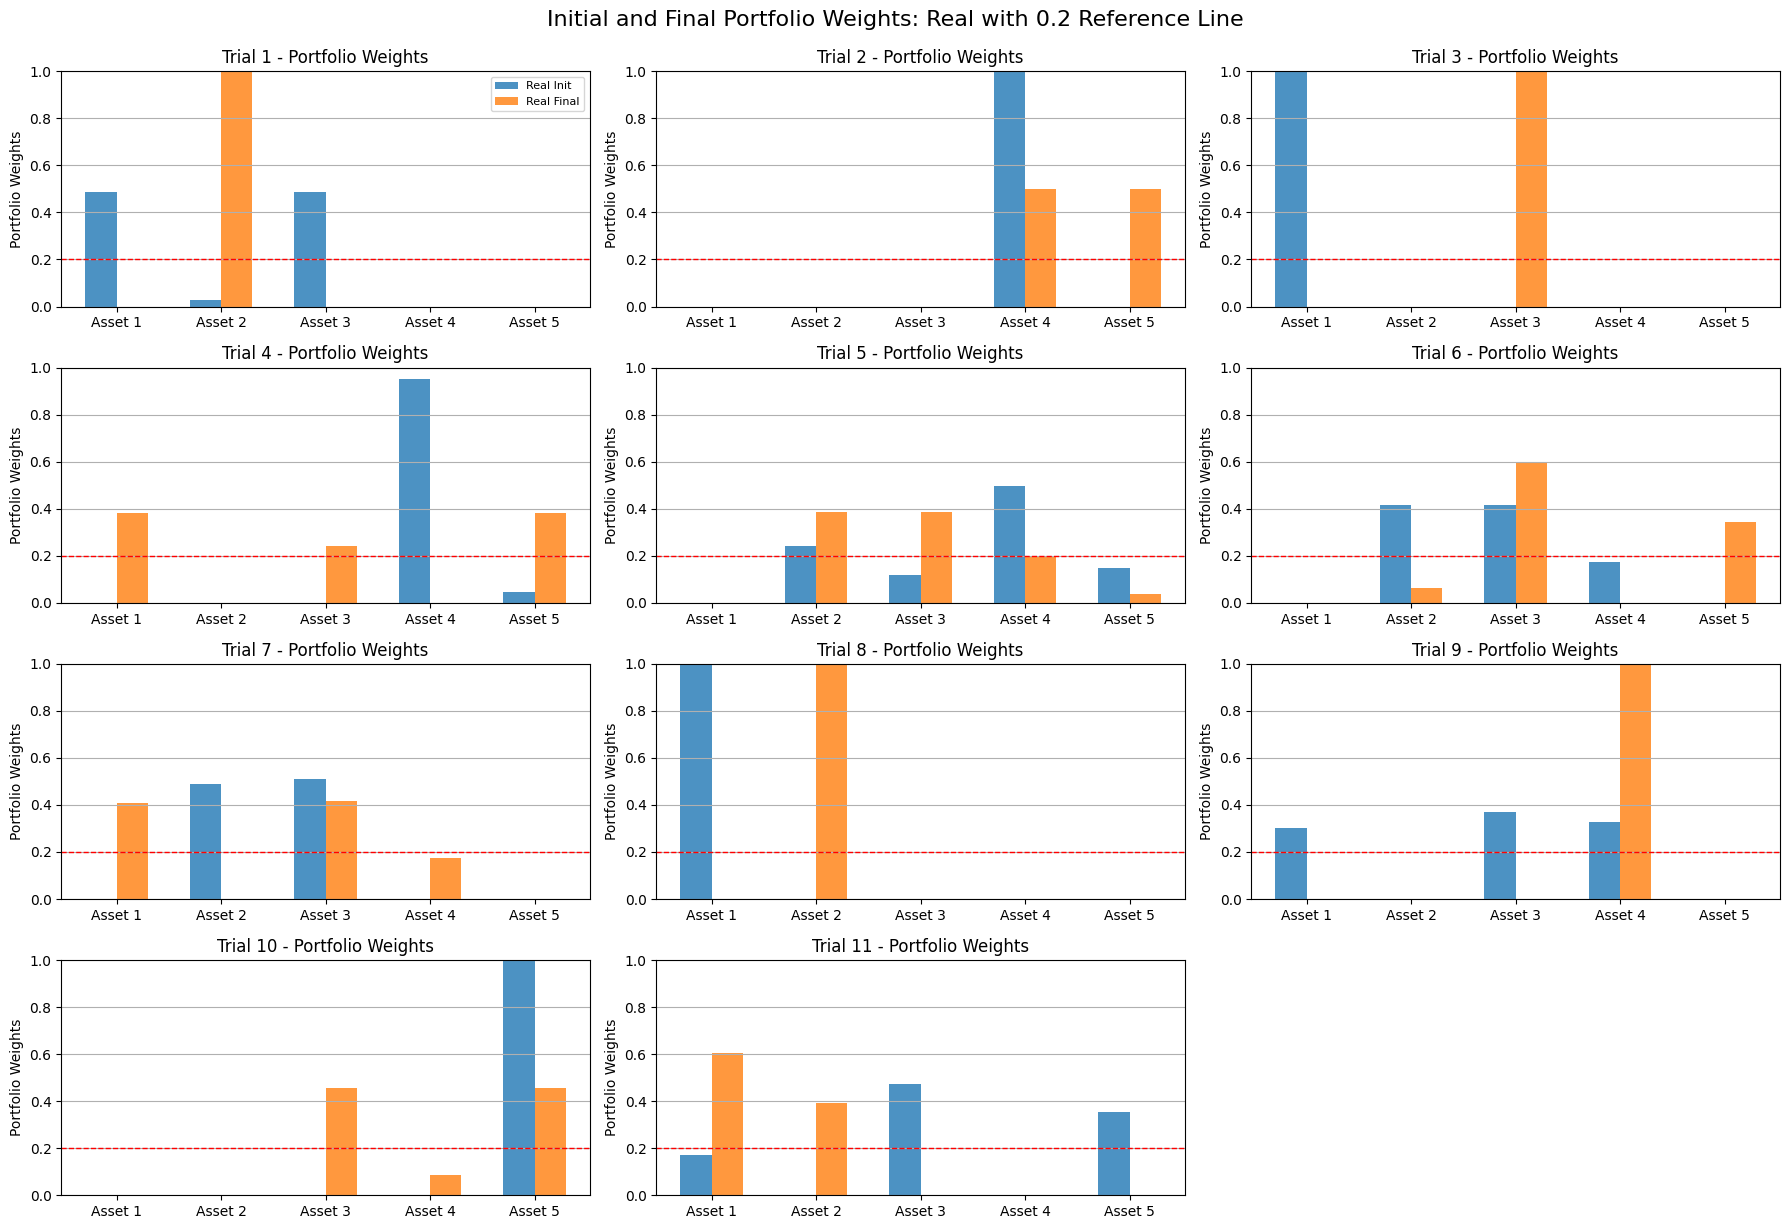

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming you already have 'paths' as a list of CSV file paths

n_assets = 5  # Number of assets
asset_labels = [f"Asset {i+1}" for i in range(n_assets)]

rows, cols = 4, 3  # subplot grid size (12 max)
fig, axs = plt.subplots(rows, cols, figsize=(18, 12))
axs = axs.flatten()

bar_width = 0.3
x = np.arange(n_assets)

for i, path in enumerate(paths):
    df = pd.read_csv(path)
    # Convert string lists to actual lists
    df["real_action"] = df["real_action"].apply(eval)

    real_init = np.array(df["real_action"].iloc[0])
    real_final = np.array(df["real_action"].iloc[-1])

    ax = axs[i]
    ax.bar(x - bar_width/2, real_init, bar_width, label='Real Init', alpha=0.8)
    ax.bar(x + bar_width/2, real_final, bar_width, label='Real Final', alpha=0.8)

    # Draw horizontal line at 0.2
    ax.axhline(y=0.2, color='red', linestyle='--', linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(asset_labels)
    ax.set_ylim(0, 1)
    ax.set_title(f"Trial {i+1} - Portfolio Weights")
    ax.set_ylabel("Portfolio Weights")
    ax.grid(axis='y')

    if i == 0:
        ax.legend(fontsize=8)

# Remove unused subplots if any
for j in range(len(paths), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.suptitle("Initial and Final Portfolio Weights: Real with 0.2 Reference Line", fontsize=16, y=1.02)
plt.show()
